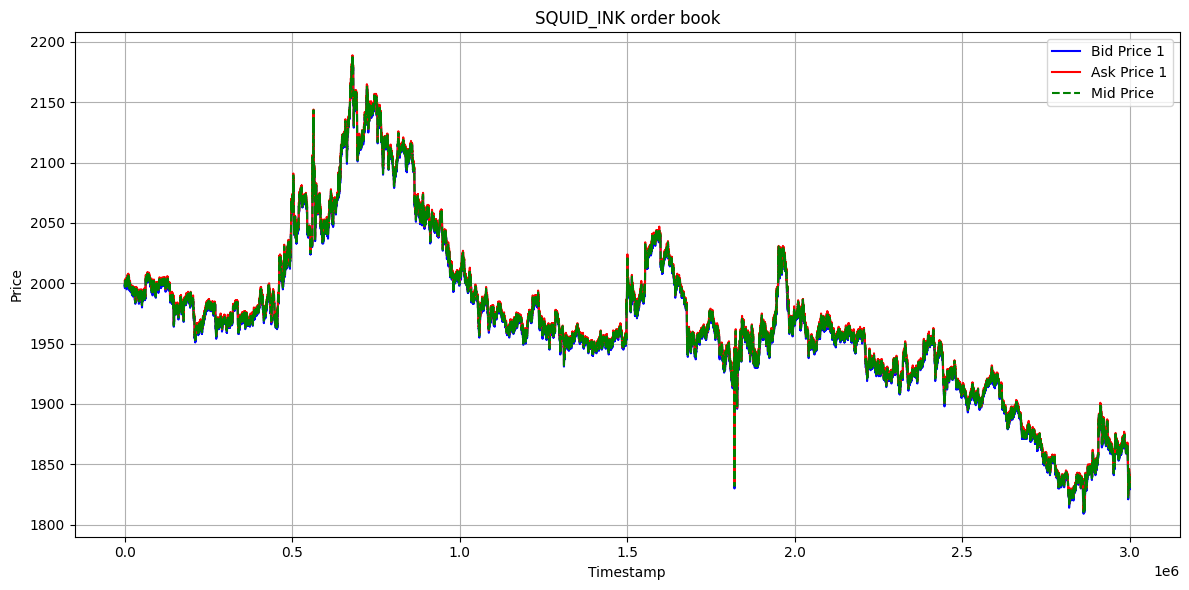

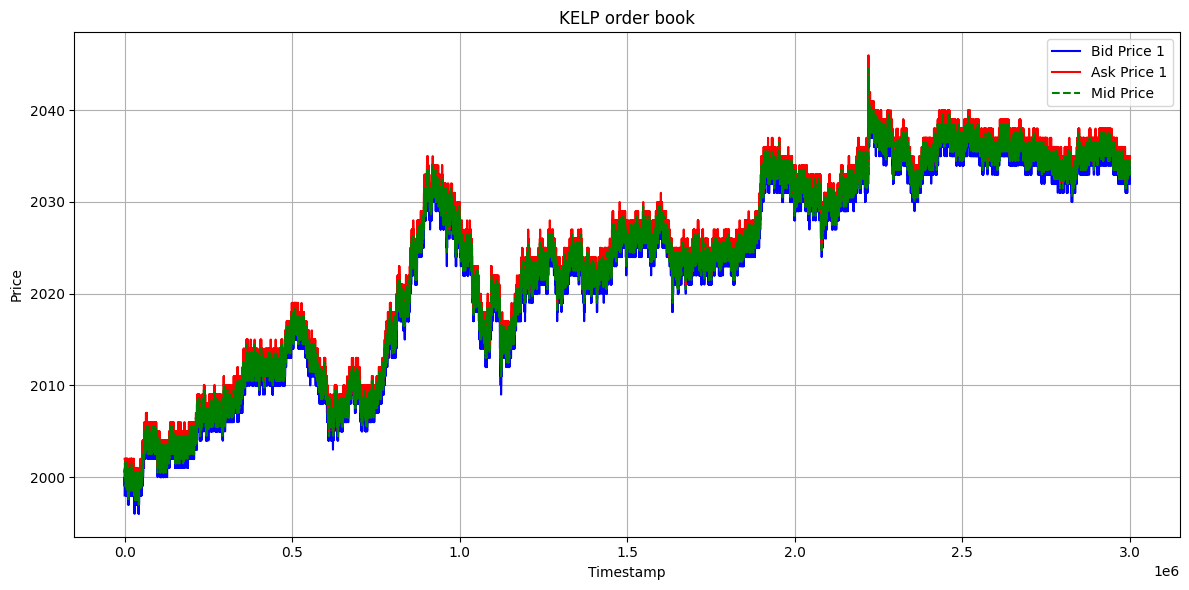

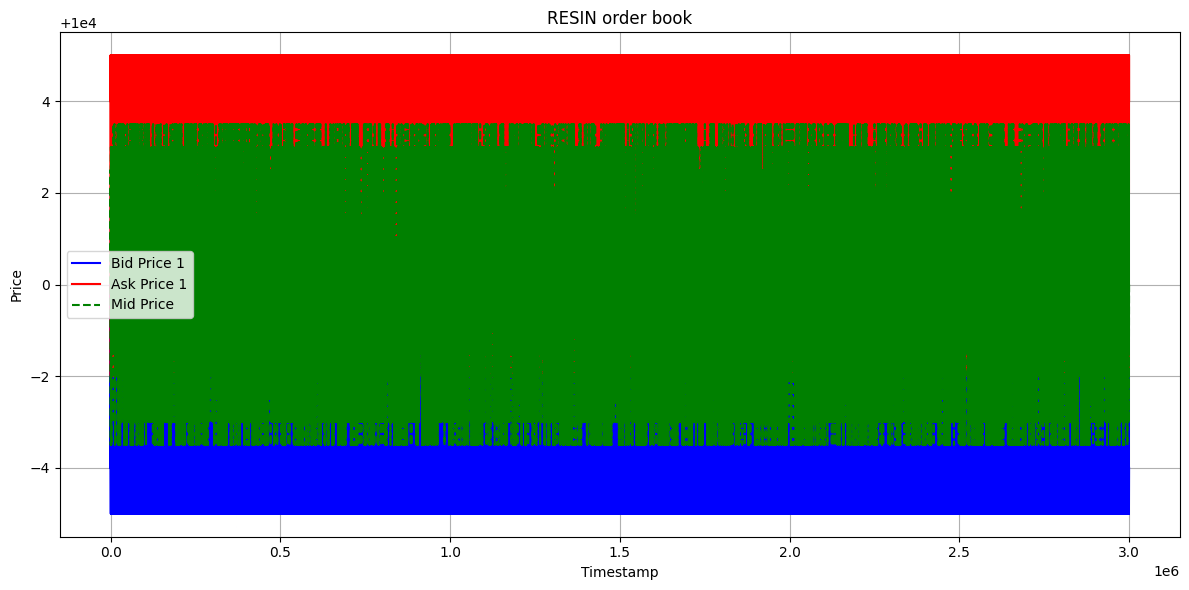

In [168]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv(r"/Users/yash/IMC-Trading/Round1/round_data/prices_round_1_day_-1.csv", sep=';')
df1['timestamp'] = pd.to_numeric(df1['timestamp'])


df2 = pd.read_csv(r"/Users/yash/IMC-Trading/Round1/round_data/prices_round_1_day_-2.csv", sep=';')
df2['timestamp'] = pd.to_numeric(df2['timestamp'])


df0 = pd.read_csv(r"/Users/yash/IMC-Trading/Round1/round_data/prices_round_1_day_0.csv", sep=';')
df0['timestamp'] = pd.to_numeric(df0['timestamp'])

df = pd.concat([df2, df1, df0], ignore_index=True, sort=True)

df['timestamp'] = df['timestamp'] + (df['day']+2)*1e6

squid_ink_df = df[df['product'] == 'SQUID_INK']
kelp_df = df[df['product'] == 'KELP']
resin_df = df[df['product'] == 'RAINFOREST_RESIN']

def plot_product_prices(product_df, product_name):
    plt.figure(figsize=(12, 6))
    plt.plot(product_df['timestamp'], product_df['bid_price_1'], label='Bid Price 1', color='blue')
    plt.plot(product_df['timestamp'], product_df['ask_price_1'], label='Ask Price 1', color='red')
    plt.plot(product_df['timestamp'], product_df['mid_price'], label='Mid Price', color='green', linestyle='--')
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.title(f"{product_name} order book")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for each product
plot_product_prices(squid_ink_df, "SQUID_INK")
plot_product_prices(kelp_df, "KELP")
plot_product_prices(resin_df, "RESIN")


In [169]:
df

,ask_price_1,ask_price_2,ask_price_3,ask_volume_1,ask_volume_2,ask_volume_3,bid_price_1,bid_price_2,bid_price_3,bid_volume_1,bid_volume_2,bid_volume_3,day,mid_price,product,profit_and_loss,timestamp
0,10004,10005.0,NaN,1,25.0,NaN,9996,9995.0,NaN,1,25.0,NaN,-2,10000.0,RAINFOREST_RESIN,0.0,0.0
1,2002,NaN,NaN,26,NaN,NaN,1998,NaN,NaN,26,NaN,NaN,-2,2000.0,KELP,0.0,0.0
2,2002,NaN,NaN,26,NaN,NaN,1998,NaN,NaN,26,NaN,NaN,-2,2000.0,SQUID_INK,0.0,0.0
3,2001,NaN,NaN,20,NaN,NaN,1999,1998.0,NaN,5,26.0,NaN,-2,2000.0,SQUID_INK,0.0,100.0
4,10005,NaN,NaN,20,NaN,NaN,10000,9995.0,NaN,5,20.0,NaN,-2,10002.5,RAINFOREST_RESIN,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,2034,2035.0,NaN,1,27.0,NaN,2032,NaN,NaN,27,NaN,NaN,0,2033.0,KELP,0.0,2999800.0
89996,10005,NaN,NaN,27,NaN,NaN,9995,NaN,NaN,27,NaN,NaN,0,10000.0,RAINFOREST_RESIN,0.0,2999800.0
89997,10004,10005.0,NaN,2,21.0,NaN,9996,9995.0,NaN,2,21.0,NaN,0,10000.0,RAINFOREST_RESIN,0.0,2999900.0
89998,1841,NaN,NaN,23,NaN,NaN,1838,NaN,NaN,23,NaN,NaN,0,1839.5,SQUID_INK,0.0,2999900.0


In [170]:
from statsmodels.tsa.stattools import adfuller

In [171]:
adfuller(squid_ink_df['mid_price'], maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-1.3839657097265103),
 np.float64(0.5899385633113557),
 41,
 29958,
 {'1%': np.float64(-3.4305683009682313),
  '5%': np.float64(-2.861636483122232),
  '10%': np.float64(-2.5668213550225185)},
 np.float64(119032.1358297965))

In [172]:
import numpy as np 

squid_differences = np.diff(squid_ink_df['mid_price'])

In [173]:
len(squid_differences), len(squid_ink_df['timestamp'])

(29999, 30000)

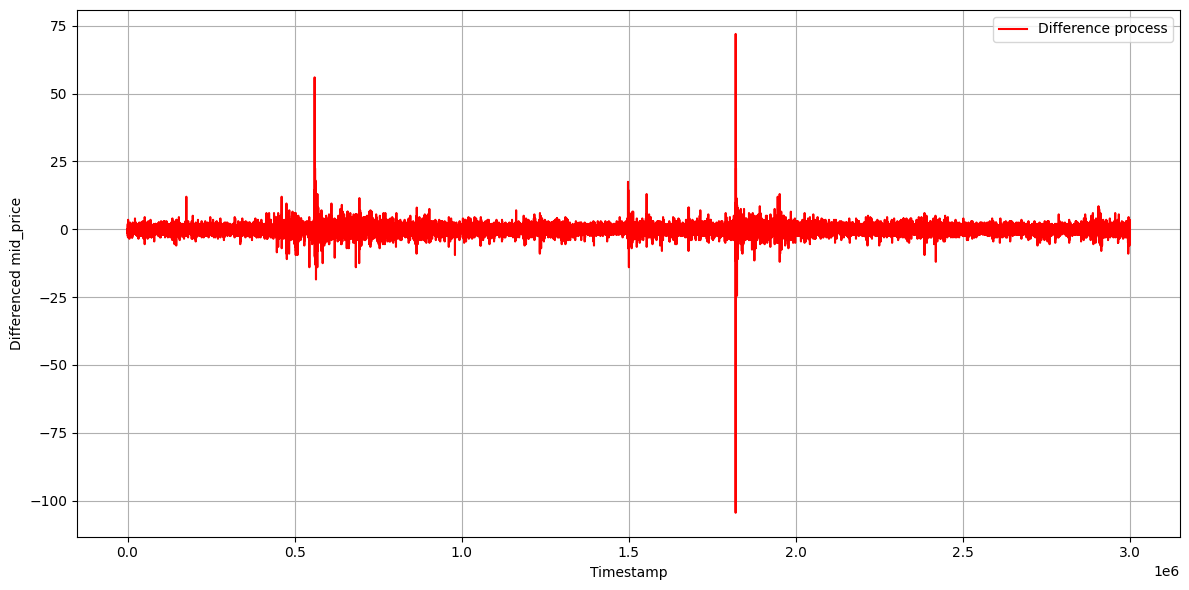

In [174]:
plt.figure(figsize = (12, 6))
plt.plot(squid_ink_df['timestamp'][1:], squid_differences, label='Difference process', color='red')
plt.legend()


plt.xlabel("Timestamp")
plt.ylabel("Differenced mid_price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [175]:
adfuller(squid_differences, maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(np.float64(-27.628007031317736),
 0.0,
 40,
 29958,
 {'1%': np.float64(-3.4305683009682313),
  '5%': np.float64(-2.861636483122232),
  '10%': np.float64(-2.5668213550225185)},
 np.float64(119028.53167268977))

In [176]:
from statsmodels.graphics.tsaplots import plot_acf

In [177]:
squid_differences.squeeze()

array([ 0. , -1.5,  0. , ...,  1.5,  3.5,  1.5], shape=(29999,))

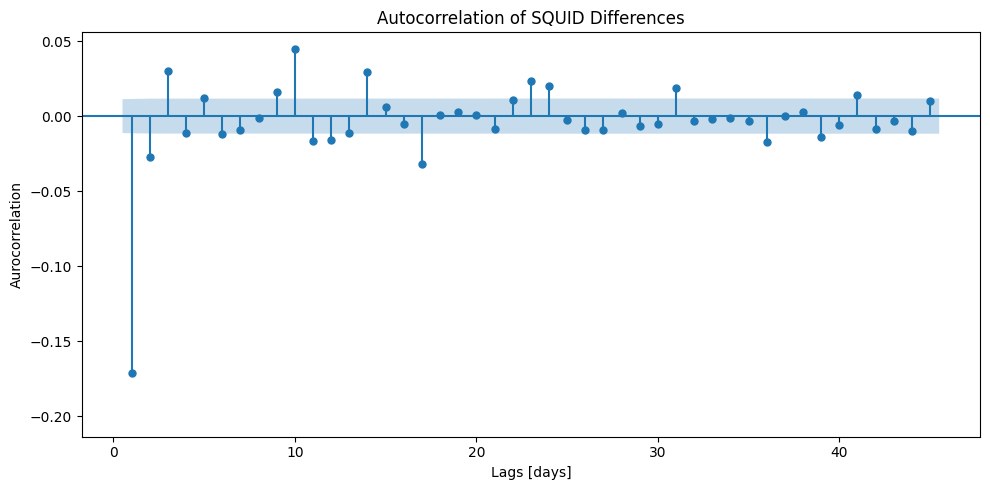

In [178]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(
    squid_differences,
    ax=ax,
    lags=None,
    alpha=0.05,
    use_vlines=True,
    adjusted=False,
    fft=False,
    missing='none',
    title='Autocorrelation of SQUID Differences',
    zero=False,
    auto_ylims=True,
    bartlett_confint=True,
    vlines_kwargs=None
)
plt.xlabel('Lags [days]')
plt.ylabel('Aurocorrelation')
plt.tight_layout()
plt.show()


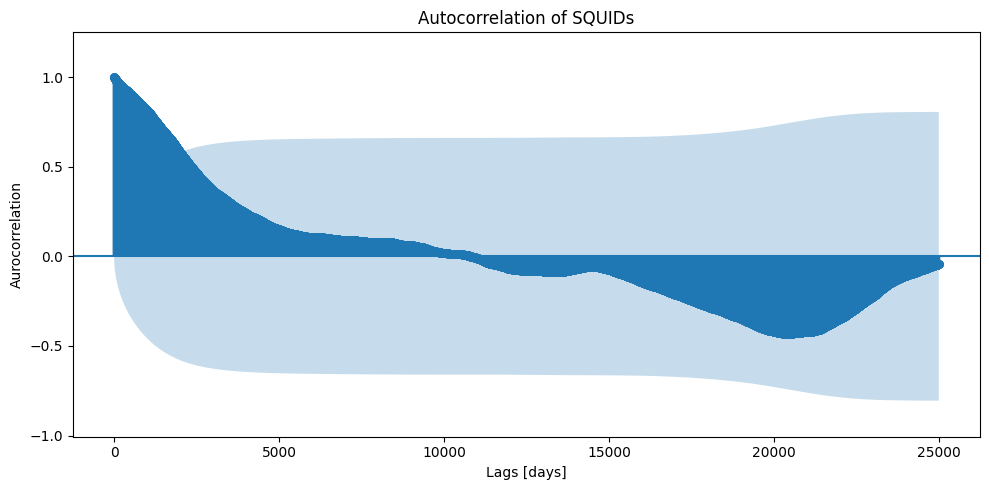

In [179]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(
    squid_ink_df['mid_price'],
    ax=ax,
    lags=25000,
    alpha=0.05,
    use_vlines=True,
    adjusted=False,
    fft=False,
    missing='none',
    title='Autocorrelation of SQUIDs',
    zero=False,
    auto_ylims=True,
    bartlett_confint=True,
    vlines_kwargs=None
)
plt.xlabel('Lags [days]')
plt.ylabel('Aurocorrelation')
plt.tight_layout()
plt.show()


Text(0.5, 0, 'Timestep')

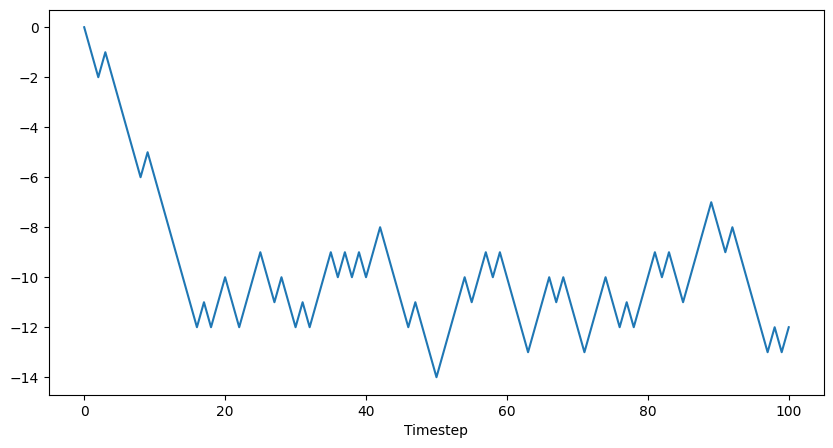

In [180]:
import random
random.seed(42)
def randomwalk(n):
    x = 0
    start = x
    xposition = [start]
    probabilities = [-1, 1]
    mu, sigma = 0, 1

    for i in range(1, n + 1):
        x += random.choice(probabilities)
        xposition.append(x)

    return xposition

n = 100
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(np.linspace(0, n, n+1), randomwalk(n))
plt.xlabel('Timestep')

In [181]:
len(randomwalk(n))

101

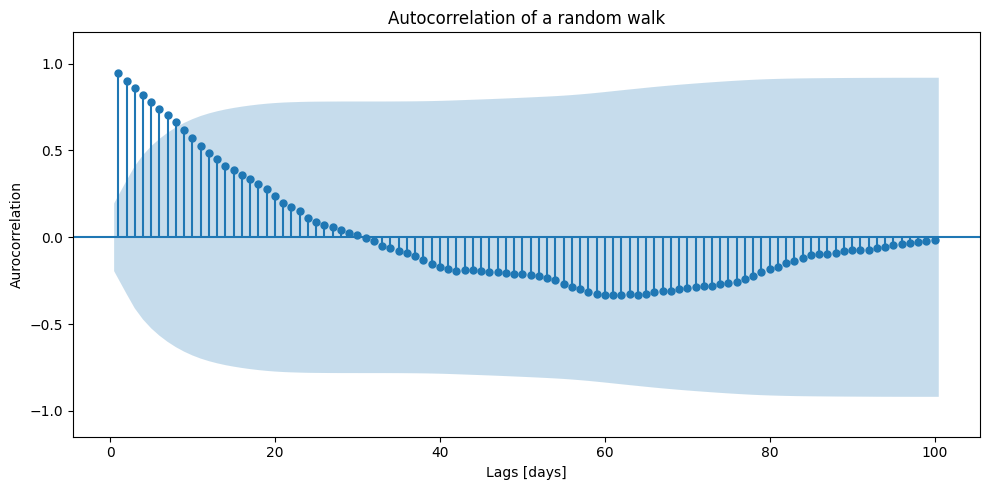

In [182]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(
    randomwalk(n),
    ax=ax,
    lags=100,
    alpha=0.05,
    use_vlines=True,
    adjusted=False,
    fft=False,
    missing='none',
    title='Autocorrelation of a random walk',
    zero=False,
    auto_ylims=True,
    bartlett_confint=True,
    vlines_kwargs=None
)
plt.xlabel('Lags [days]')
plt.ylabel('Aurocorrelation')
plt.tight_layout()
plt.show()


In [183]:
squid_ink_df

,ask_price_1,ask_price_2,ask_price_3,ask_volume_1,ask_volume_2,ask_volume_3,bid_price_1,bid_price_2,bid_price_3,bid_volume_1,bid_volume_2,bid_volume_3,day,mid_price,product,profit_and_loss,timestamp
2,2002,NaN,NaN,26,NaN,NaN,1998,NaN,NaN,26,NaN,NaN,-2,2000.0,SQUID_INK,0.0,0.0
3,2001,NaN,NaN,20,NaN,NaN,1999,1998.0,NaN,5,26.0,NaN,-2,2000.0,SQUID_INK,0.0,100.0
7,2000,2001.0,NaN,1,30.0,NaN,1997,NaN,NaN,31,NaN,NaN,-2,1998.5,SQUID_INK,0.0,200.0
11,2000,NaN,NaN,27,NaN,NaN,1997,NaN,NaN,27,NaN,NaN,-2,1998.5,SQUID_INK,0.0,300.0
14,2000,NaN,NaN,20,NaN,NaN,1996,NaN,NaN,20,NaN,NaN,-2,1998.0,SQUID_INK,0.0,400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89986,1833,NaN,NaN,28,NaN,NaN,1830,NaN,NaN,28,NaN,NaN,0,1831.5,SQUID_INK,0.0,2999500.0
89989,1834,1835.0,NaN,2,27.0,NaN,1832,1831.0,NaN,7,29.0,NaN,0,1833.0,SQUID_INK,0.0,2999600.0
89993,1835,NaN,NaN,26,NaN,NaN,1834,1832.0,NaN,1,26.0,NaN,0,1834.5,SQUID_INK,0.0,2999700.0
89994,1839,1840.0,NaN,1,27.0,NaN,1837,NaN,NaN,27,NaN,NaN,0,1838.0,SQUID_INK,0.0,2999800.0


In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [ ]:
# Assuming squid_ink_df is already defined with a 'mid_price' column
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)
    
    return dftest[1] <= 0.05

# Test stationarity
is_stationary = test_stationarity(squid_ink_df['mid_price'])

Results of Dickey-Fuller Test:
Test Statistic                    -1.383966
p-value                            0.589939
#Lags Used                        41.000000
Number of Observations Used    29958.000000
Critical Value (1%)               -3.430568
Critical Value (5%)               -2.861636
Critical Value (10%)              -2.566821
dtype: float64


In [186]:
# If not stationary, difference the series
if not is_stationary:
    print("Series is not stationary. Applying differencing.")
    diff_series = squid_ink_df['mid_price'].diff().dropna()
    is_diff_stationary = test_stationarity(diff_series)
    
    if is_diff_stationary:
        print("Differenced series is stationary.")
    else:
        print("Differenced series is still not stationary. Consider further differencing.")
        diff2_series = diff_series.diff().dropna()
        is_diff2_stationary = test_stationarity(diff2_series)
        
        if is_diff2_stationary:
            print("Second-order differenced series is stationary.")

Series is not stationary. Applying differencing.
Results of Dickey-Fuller Test:
Test Statistic                   -27.628007
p-value                            0.000000
#Lags Used                        40.000000
Number of Observations Used    29958.000000
Critical Value (1%)               -3.430568
Critical Value (5%)               -2.861636
Critical Value (10%)              -2.566821
dtype: float64
Differenced series is stationary.


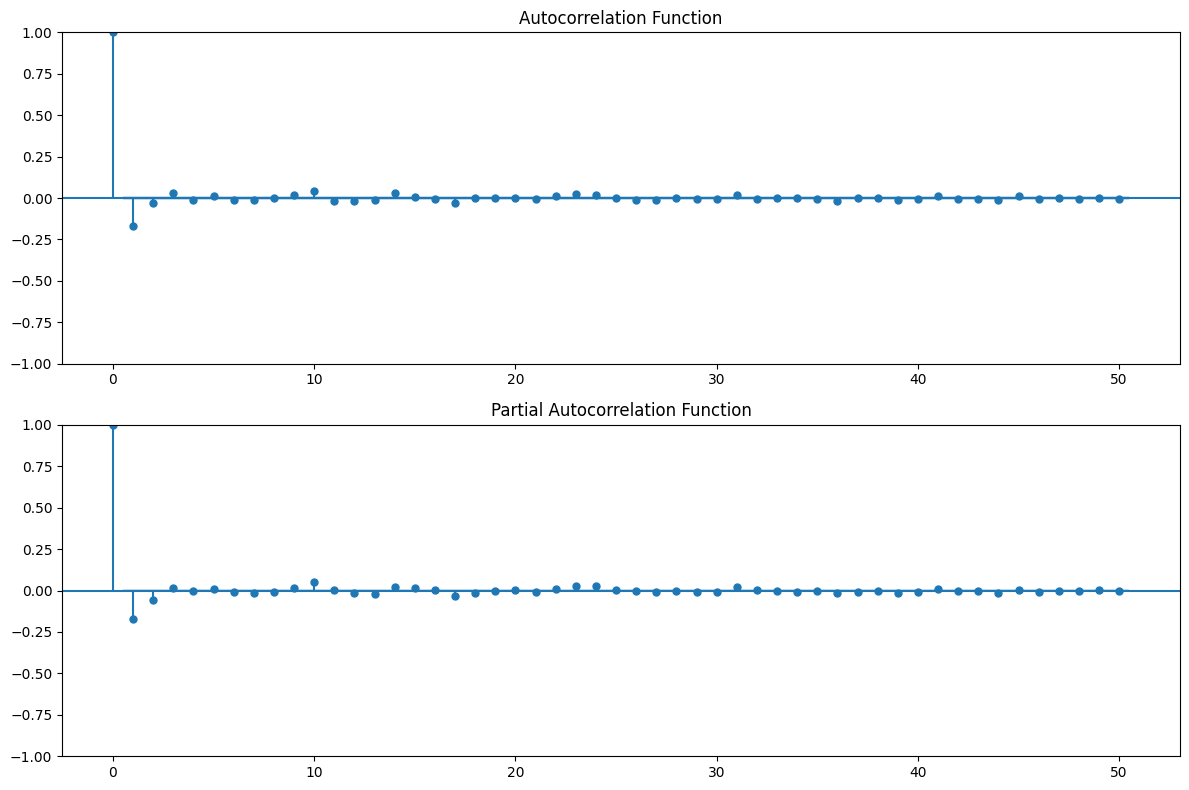

In [187]:
# Plot ACF and PACF to identify potential p and q values
plt.figure(figsize=(12, 8))
plt.subplot(211)
plot_acf(squid_ink_df['mid_price'].diff().dropna() if not is_stationary else squid_ink_df['mid_price'], 
         lags=50, ax=plt.gca(), title='Autocorrelation Function')
plt.subplot(212)
plot_pacf(squid_ink_df['mid_price'].diff().dropna() if not is_stationary else squid_ink_df['mid_price'], 
          lags=50, ax=plt.gca(), title='Partial Autocorrelation Function')
plt.tight_layout()
plt.show()

In [ ]:
# Based on the ACF/PACF and stationarity test, define the ARIMA model
# Default parameters if identification is unclear
p, d, q = 1, 1, 1  # These should be adjusted based on ACF/PACF plots

if is_stationary:
    d = 0
else:
    d = 1 if is_diff_stationary else 2

In [210]:
squid_ink_df.columns

Index(['ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_volume_1',
       'ask_volume_2', 'ask_volume_3', 'bid_price_1', 'bid_price_2',
       'bid_price_3', 'bid_volume_1', 'bid_volume_2', 'bid_volume_3', 'day',
       'mid_price', 'product', 'profit_and_loss', 'timestamp'],
      dtype='object')

In [211]:
squid_mp = pd.DataFrame()
squid_mp['midprice'] = squid_ink_df['mid_price']

In [230]:
squid_mp.columns

import pandas as pd
from datetime import datetime, timedelta
start_date = datetime(2023, 1, 1)
date_range = pd.date_range(start=start_date, periods=30000, freq='1min')

squid_mp.index = date_range

In [227]:
squid_mp['Index'] = np.arange(0, 30000, 1)
squid_mp.set_index('Index', inplace=True)

In [231]:
squid_mp

,midprice
2023-01-01 00:00:00,2000.0
2023-01-01 00:01:00,2000.0
2023-01-01 00:02:00,1998.5
2023-01-01 00:03:00,1998.5
2023-01-01 00:04:00,1998.0
...,...
2023-01-21 19:55:00,1831.5
2023-01-21 19:56:00,1833.0
2023-01-21 19:57:00,1834.5
2023-01-21 19:58:00,1838.0


In [234]:
model = ARIMA(squid_mp['midprice'], order=(1, 1, 1))
model_fit = model.fit()

In [235]:
squid_mp

,midprice
2023-01-01 00:00:00,2000.0
2023-01-01 00:01:00,2000.0
2023-01-01 00:02:00,1998.5
2023-01-01 00:03:00,1998.5
2023-01-01 00:04:00,1998.0
...,...
2023-01-21 19:55:00,1831.5
2023-01-21 19:56:00,1833.0
2023-01-21 19:57:00,1834.5
2023-01-21 19:58:00,1838.0


In [236]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               midprice   No. Observations:                30000
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -59712.334
Date:                Mon, 07 Apr 2025   AIC                         119430.668
Time:                        18:43:47   BIC                         119455.595
Sample:                    01-01-2023   HQIC                        119438.666
                         - 01-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0746      0.005     14.464      0.000       0.064       0.085
ma.L1         -0.2554      0.005    -48.700      0.000      -0.266      -0.245
sigma2         3.1364      0.002   1847.043      0.0

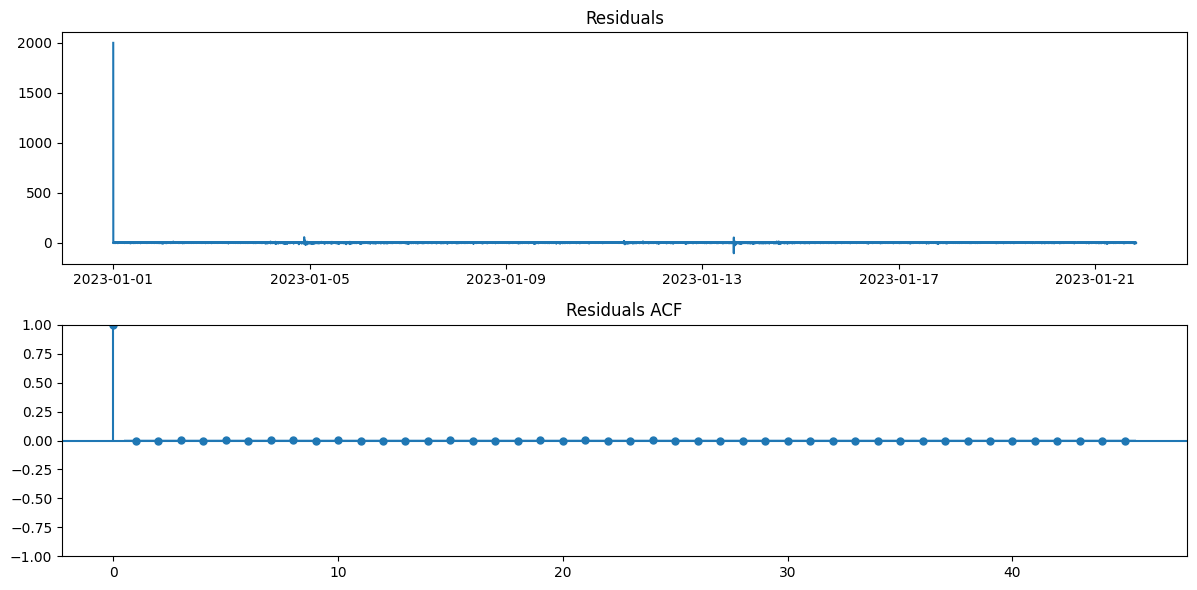

In [237]:
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(model_fit.resid)
plt.title('Residuals')
plt.subplot(212)
plot_acf(model_fit.resid, ax=plt.gca(), title='Residuals ACF')
plt.tight_layout()
plt.show()